<a href="https://colab.research.google.com/github/Alamsyah-WM/Classification-DBP-Binding-vs-Non-Binding/blob/Finale/MLP_ESM1b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Preparation

In [14]:
# Install fair-esm if not present
!pip install fair-esm -q
!pip install torch torchvision torchaudio
!pip install fair-esm scikit-learn pandas numpy tqdm

# --- IMPORTING LIBRARIES ---
import esm
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from tqdm import tqdm

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cuda


# Data Preprocessing

In [15]:
# A. Cleaning Function
def cleaning_dataset(df, dataset_name=None):
    if df is None or df.empty:
        print(f'Dataset {dataset_name} is empty. No clean required')
        return df

    # Check if 'set' column exists (used for existing splits)
    if 'set' in df.columns:
        df_sorted = df.sort_values(by='set', ascending=True)
        # Drop duplicates based on sequence, keeping first found
        df_clean = df_sorted.drop_duplicates(subset='sequence', keep='first').reset_index(drop=True)
    else:
        df_clean = df.drop_duplicates(subset='sequence', keep='first').reset_index(drop=True)

    print(f'Dataset {dataset_name} cleaned: {len(df)} -> {len(df_clean)} rows')
    return df_clean

# B. Sequence Windowing (For sequences > 1022 AA)
def window_sliding(seq, max_len=1022, stride=512):
    if len(seq) <= max_len:
        return [seq]
    chunks = []
    for i in range(0, len(seq), stride):
        chunk = seq[i:i + max_len]
        # skip fragments too short to be meaningful
        if len(chunk) < 50:
            continue
        chunks.append(chunk)
    return chunks

# C. Embedding Generation
def extract_esm_embeddings(sequences, model, batch_converter, device, batch_size=8):
    """Extract mean ESM-1b embeddings with automatic windowing for long proteins."""
    all_embeddings = []
    truncated_count = 0

    model.eval()

    for seq in tqdm(sequences, desc="Extracting ESM embeddings"):
        subseqs = window_sliding(seq)
        if len(seq) > 1022:
            truncated_count += 1

        subseq_embeddings = []
        # Process windows in batches
        for i in range(0, len(subseqs), batch_size):
            batch = subseqs[i:i + batch_size]
            batch_data = [("", s) for s in batch]
            batch_labels, batch_strs, batch_tokens = batch_converter(batch_data)
            batch_tokens = batch_tokens.to(device)

            with torch.no_grad():
                results = model(batch_tokens, repr_layers=[33])
                reps = results["representations"][33]

            for j, s in enumerate(batch):
                # Mean pooling over sequence length (excluding padding handled by slicing)
                emb = reps[j, 1:len(s)+1].mean(0).cpu().numpy()
                subseq_embeddings.append(emb)

        # Average all windows for this protein
        mean_embedding = np.mean(subseq_embeddings, axis=0)
        all_embeddings.append(mean_embedding)

    print(f"Sequences truncated (>1022 aa): {truncated_count}")
    return np.vstack(all_embeddings)

# D. Main Data Pipeline Function
def prepare_data(csv_path, output_dir, dataset_name="dataset"):
    """
    Pipeline: Load CSV -> Clean -> Check Cache -> (Generate Embeddings -> Save) -> Return Data
    """
    # Paths for cached files
    os.makedirs(output_dir, exist_ok=True)
    train_emb_path = os.path.join(output_dir, f"x_{dataset_name}_train.pt")
    test_emb_path = os.path.join(output_dir, f"x_{dataset_name}_test.pt")
    train_lbl_path = os.path.join(output_dir, f"y_{dataset_name}_train.npy")
    test_lbl_path = os.path.join(output_dir, f"y_{dataset_name}_test.npy")

    # 1. Check if cache exists
    if os.path.exists(train_emb_path) and os.path.exists(test_lbl_path):
        print(f"Loading cached embeddings from {output_dir}...")
        X_train = torch.load(train_emb_path)
        y_train = np.load(train_lbl_path)
        X_test = torch.load(test_emb_path)
        y_test = np.load(test_lbl_path)
        return X_train, y_train, X_test, y_test

    print(f"Cache not found. Processing {csv_path}...")

    # 2. Load and Clean
    df = pd.read_csv(csv_path)
    df = cleaning_dataset(df, dataset_name)

    # 3. Split (using 'set' column if available, else random split)
    if 'set' in df.columns:
        train_df = df[df['set'] == 'train']
        test_df = df[df['set'] == 'test']
    else:
        from sklearn.model_selection import train_test_split
        print("No 'set' column found. Performing random 80/20 split.")
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    sequences_train = train_df['sequence'].tolist()
    labels_train = train_df['label'].values
    sequences_test = test_df['sequence'].tolist()
    labels_test = test_df['label'].values

    # --- ADDED: Print split info ---
    print(f"Data Split - Train: {len(sequences_train)} rows, Test: {len(sequences_test)} rows")
    # -------------------------------

    # 4. Initialize ESM Model
    print("Loading ESM-1b Model...")
    model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
    batch_converter = alphabet.get_batch_converter()
    model = model.eval().to(device)

    # 5. Generate Embeddings
    print("Generating Train embeddings...")
    X_train_emb = extract_esm_embeddings(sequences_train, model, batch_converter, device)
    print("Generating Test embeddings...")
    X_test_emb = extract_esm_embeddings(sequences_test, model, batch_converter, device)

    # 6. Save Cache
    print("Saving embeddings to cache...")
    # Convert to Tensor for PyTorch compatibility
    X_train_tensor = torch.tensor(X_train_emb).float()
    X_test_tensor = torch.tensor(X_test_emb).float()

    torch.save(X_train_tensor, train_emb_path)
    torch.save(X_test_tensor, test_emb_path)
    np.save(train_lbl_path, labels_train)
    np.save(test_lbl_path, labels_test)

    return X_train_tensor, labels_train, X_test_tensor, labels_test

# Model Architecture

In [16]:
class SequenceDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features if isinstance(features, torch.Tensor) else torch.tensor(features).float()
        self.labels = labels if isinstance(labels, torch.Tensor) else torch.tensor(labels).long()
    def __len__(self): return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

class ComplexMLP_v2(nn.Module):
    def __init__(self, input_dim=1280, num_classes=2, hidden_dim=512, dropout_rate=0.3):
        super(ComplexMLP_v2, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.BatchNorm1d(hidden_dim // 4),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 4, hidden_dim // 8),
            nn.BatchNorm1d(hidden_dim // 8),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_dim // 8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


# Visualize

In [17]:
def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(10, 6))

    # Primary Axis: Loss (Blue)
    ax1 = plt.gca()
    l1 = ax1.plot(epochs, history['train_loss'], label='Train Loss', color='tab:blue')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    # Secondary Axis: Accuracy (Orange)
    ax2 = ax1.twinx()
    l2 = ax2.plot(epochs, history['val_acc'], label='Val Acc', color='tab:orange')
    ax2.set_ylabel('Accuracy', color='tab:orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax2.set_ylim(0, 1.05) # Accuracy is always 0-1

    # Combined Title & Legend
    plt.title('Training Loss & Validation Accuracy per Epoch', fontsize=14)
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')

    plt.tight_layout()
    plt.show()
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()


# Training Function

In [18]:
def evaluate_model(model, dataloader, device='cuda', return_preds=False):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            prob = torch.softmax(outputs, dim=1)
            pred = torch.argmax(prob, dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(prob.cpu().numpy())
    y_true, y_pred, y_probs = np.array(all_labels), np.array(all_preds), np.array(all_probs)[:, 1]

    # Check if we have both classes for AUC
    if len(np.unique(y_true)) > 1:
        roc_auc = roc_auc_score(y_true, y_probs)
    else:
        roc_auc = 0.0
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    # Specificity
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        spec = tn / (tn + fp)
    except ValueError:
        spec = 0.0 # Handle edge cases
        tn, fp, fn, tp = 0, 0, 0, 0
    metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "Specificity": spec, "F1_Score": f1, "ROC_AUC": roc_auc}

    if return_preds:
        return metrics, y_true, y_pred, y_probs
    return metrics

def train_model_v3(model, train_loader, val_loader, train_labels_for_weighting, epochs=50, lr=1e-3, weight_decay=1e-4, patience=10, device='cuda', save_path="mlp_esm1b_best.pth"):
    # Calculate Class Weights
    class_counts = np.bincount(train_labels_for_weighting)
    total_samples = len(train_labels_for_weighting)
    class_weights = total_samples / class_counts
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f"Using Class Weights: {weights_tensor.cpu().numpy()}")

    # Weighted Loss
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=5, factor=0.5)

    best_acc = 0.0
    patience_counter = 0
    history = {'train_loss': [], 'val_acc': []}

    model.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X); loss = criterion(outputs, y)
            loss.backward(); optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss/len(train_loader)
        history['train_loss'].append(avg_loss)

        if val_loader:
            val_metrics = evaluate_model(model, val_loader, device=device)
            val_acc = val_metrics['Accuracy']
            history['val_acc'].append(val_acc)
            print(f"Epoch [{epoch}/{epochs}] Loss: {avg_loss:.4f} Val Acc: {val_acc:.4f}")
            scheduler.step(val_acc)

            if val_acc > best_acc:
                best_acc = val_acc
                patience_counter = 0
                torch.save(model.state_dict(), save_path)
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered at epoch {epoch}.")
                    break

    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
    return model, history


# Main Execution

--- Step 1: Preparing Data (Source: /content/UniSwiss.csv) ---
Cache not found. Processing /content/UniSwiss.csv...
Dataset UniSwiss cleaned: 9762 -> 9696 rows
Data Split - Train: 8937 rows, Test: 759 rows
Loading ESM-1b Model...
Generating Train embeddings...


Extracting ESM embeddings: 100%|██████████| 8937/8937 [50:01<00:00,  2.98it/s]


Sequences truncated (>1022 aa): 735
Generating Test embeddings...


Extracting ESM embeddings: 100%|██████████| 759/759 [04:12<00:00,  3.01it/s]


Sequences truncated (>1022 aa): 64
Saving embeddings to cache...

Splitting Training Data to create Validation Set (Size: 759)...
Final Input Shapes - Train: torch.Size([8178, 1280]), Val: torch.Size([759, 1280]), Test: torch.Size([759, 1280])

--- Step 2: Training MLP (Try 3 Logic) ---
ComplexMLP_v2(
  (network): Sequential(
    (0): Linear(in_features=1280, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_features=6

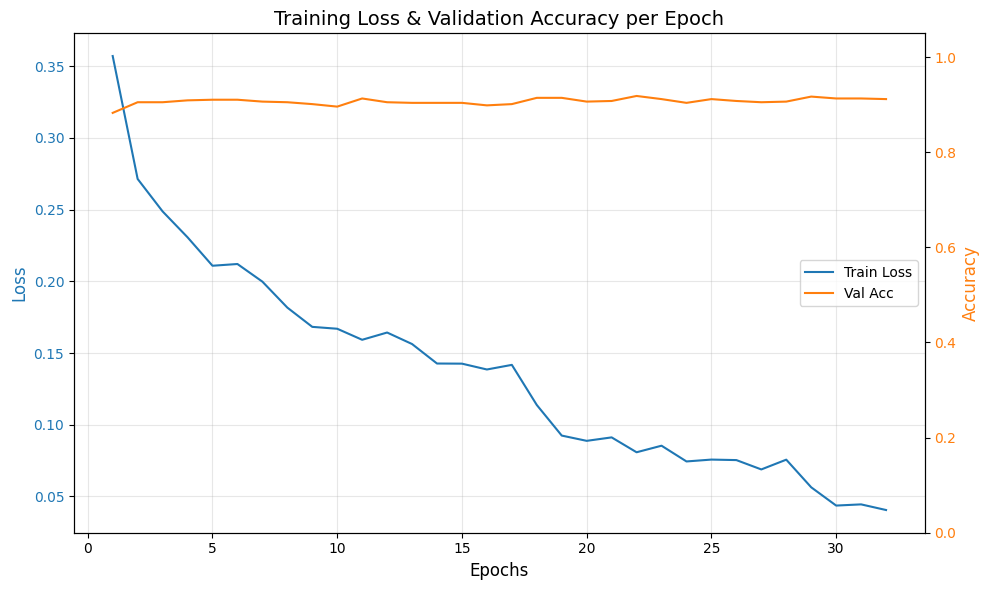


Evaluating on TEST Set (Unseen Data)...
Test Accuracy:    0.9144
Test Precision:   0.9311
Test Recall:      0.8942
Test Specificity: 0.9344
Test F1 Score:    0.9123
Test ROC-AUC:     0.9628

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       381
           1       0.93      0.89      0.91       378

    accuracy                           0.91       759
   macro avg       0.92      0.91      0.91       759
weighted avg       0.91      0.91      0.91       759



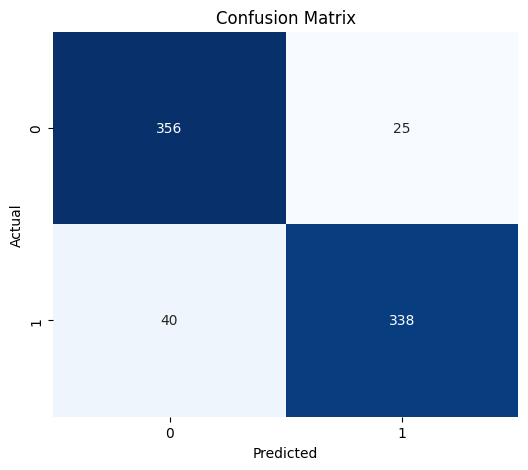


--- Done. Model Saved to mlp_esm1b_best.pth ---


In [20]:
if __name__ == "__main__":
    # Configuration
    csv_path = "/content/UniSwiss.csv"  # Replace with actual path
    output_dir = "esm_embed/DL/UniSwiss"

    print(f"--- Step 1: Preparing Data (Source: {csv_path}) ---")
    X_train_full, y_train_full, X_test, y_test = prepare_data(csv_path, output_dir, dataset_name="UniSwiss")

    # Split for Validation
    from sklearn.model_selection import train_test_split
    val_size = len(X_test)
    if len(X_train_full) > val_size:
        print(f"\nSplitting Training Data to create Validation Set (Size: {val_size})...")
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=val_size,
            random_state=42,
            stratify=y_train_full
        )
    else:
        print("\nWarning: Training set too small. Using Test set as Validation.")
        X_train, y_train = X_train_full, y_train_full
        X_val, y_val = X_test, y_test

    print(f"Final Input Shapes - Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

    train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(SequenceDataset(X_val, y_val), batch_size=32)
    test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=32)

    print("\n--- Step 2: Training MLP (Try 3 Logic) ---")
    # Initialize ComplexMLP_v2
    model = ComplexMLP_v2(input_dim=1280, num_classes=2, hidden_dim=512, dropout_rate=0.3)
    print(model)

    # Train using train_model_v3 (Weighted Loss)
    trained_model, history = train_model_v3(
        model,
        train_loader,
        val_loader,
        train_labels_for_weighting=y_train, # Pass labels for weighting
        epochs=50,
        save_path="mlp_esm1b_uniswiss_best.pth"
    )

    print("\n--- Step 3: Visualization & Evaluation ---")
    plot_training_history(history)

    print("\nEvaluating on TEST Set (Unseen Data)...")
    metrics, y_true, y_pred, y_probs = evaluate_model(trained_model, test_loader, device=device, return_preds=True)

    print(f"Test Accuracy:    {metrics['Accuracy']:.4f}")
    print(f"Test Precision:   {metrics['Precision']:.4f}")
    print(f"Test Recall:      {metrics['Recall']:.4f}")
    print(f"Test Specificity: {metrics['Specificity']:.4f}")
    print(f"Test F1 Score:    {metrics['F1_Score']:.4f}")
    print(f"Test ROC-AUC:     {metrics['ROC_AUC']:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    plot_confusion_matrix(y_true, y_pred)
    print("\n--- Done. Model Saved to mlp_esm1b_best.pth ---")